# Fig5_nichespace_clustering.ipynb

This notebook demonstrates clustering of species niche spaces, drawing dendrograms, visualizing average niche spaces, and performing related calculations and plots.

In [1]:
from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, convert_to_env_list_detail
import yaml
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.decomposition import PCA
import math
import feather
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, set_link_color_palette
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib as mpl
from scipy.stats import skewnorm
import matplotlib.ticker as mtick
from matplotlib.ticker import ScalarFormatter

# Set default matplotlib parameters.
set_mpl_defaults()

## Define run and experiment IDs
The PlotUtlis class uses these IDs to locate various data and configuration paths.

In [2]:
run_id = 'a21e809cf92c477c8e6f67a638adcb03'
exp_id = '560401789505105998'

## Initialize PlotUtlis
This instantiates the PlotUtlis object, which provides convenience methods for data loading, saving, and plotting.

In [3]:
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

## Create directory for niche space clustering plots
Ensures the target directory exists for saving our clustering figures.

In [4]:
create_folder(PU.plot_path_nichespace_clustering)

### Translate species name to Chinese

In [5]:
# df_name = pd.read_csv('./raw/data/nvdimp_subplot.csv')
# sciname = list(set(df_name.scientificName))
# chiname = [df_name[df_name['scientificName'] == s_n]['vernacularName'].value_counts().idxmax() if len(set(df_name[df_name['scientificName'] == s_n]['vernacularName']))>1 else list(set(df_name[df_name['scientificName'] == s_n]['vernacularName']))[0] for s_n in sciname]
# pd.DataFrame({'sciname': sciname, 'chiname': chiname}).to_csv(os.path.join(PU.plot_path_nichespace_clustering, 'change_name.csv'), index = None)

## Retrieve DeepSDM niche space data
Loads precomputed niche space arrays for each species from disk.

In [6]:
# these are TREES
species_list_tree = ['Debregeasia_orientalis', 'Neolitsea_hiiranensis', 'Capparis_micracantha', 'Berberis_mingetsensis', 'Radermachera_sinica', 'Cinnamomum_osmophloeum', 'Cleyera_japonica_var._taipinensis', 'Acer_serrulatum', 'Vaccinium_randaiense', 'Acer_albopurpurascens', 'Polyspora_axillaris', 'Enkianthus_perulatus', 'Machilus_zuihoensis_var._mushaensis', 'Turpinia_formosana', 'Sarcopyramis_napalensis_var._delicata', 'Lithocarpus_harlandii', 'Distyliopsis_dunnii', 'Rubus_formosensis', 'Terminalia_catappa', 'Derris_trifoliata', 'Vernicia_montana', 'Pittosporum_daphniphylloides', 'Trachelospermum_formosanum', 'Macaranga_tanarius', 'Quercus_pachyloma', 'Hydrangea_longifolia', 'Champereia_manillana', 'Dodonaea_viscosa', 'Aeschynanthus_acuminatus', 'Salix_fulvopubescens_var._doii', 'Vernicia_fordii', 'Bombax_ceiba', 'Grewia_rhombifolia', 'Berchemia_lineata', 'Croton_cascarilloides', 'Calocedrus_macrolepis_var._formosana', 'Euonymus_laxiflorus', 'Lepisorus_pseudoussuriensis', 'Actinidia_callosa_var._discolor', 'Crateva_adansonii_subsp._formosensis', 'Vaccinium_kengii', 'Diospyros_oldhamii', 'Castanopsis_eyrei', 'Heptapleurum_heptaphyllum', 'Neolitsea_acuminatissima', 'Ficus_erecta_var._beecheyana', 'Ventilago_leiocarpa', 'Syzygium_densinervium', 'Drypetes_karapinensis', 'Randia_sinensis', 'Lantana_camara', 'Taiwania_cryptomerioides', 'Elaeocarpus_decipiens', 'Ficus_variegata_var._variegata', 'Cayratia_japonica', 'Lagerstroemia_subcostata', 'Ardisia_crenata', 'Triadica_cochinchinensis', 'Kadsura_japonica', 'Albizia_julibrissin', 'Symplocos_koshunensis', 'Nageia_nagi', 'Bretschneidera_sinensis', 'Margaritaria_indica', 'Smilax_bracteata_var._verruculosa', 'Microtropis_japonica', 'Schisandra_arisanensis', 'Euonymus_pallidifolia', 'Oreocnide_pedunculata', 'Ormosia_hengchuniana', 'Aristolochia_kaempferi', 'Osmanthus_matsumuranus', 'Osmanthus_lanceolatus', 'Premna_octonervia', 'Palaquium_formosanum', 'Cinnamomum_insularimontanum', 'Celastrus_kusanoi', 'Syzygium_jambos', 'Hibiscus_syriacus', 'Symplocos_formosana', 'Myrica_adenophora', 'Ficus_subpisocarpa', 'Rubus_kawakamii', 'Camphora_officinarum', 'Actinidia_setosa', 'Zanthoxylum_scandens', 'Lonicera_acuminata', 'Machilus_japonica_var._kusanoi', 'Manihot_esculenta', 'Tetrastigma_bioritsense', 'Ilex_crenata', 'Ilex_tugitakayamensis', 'Styrax_suberifolia', 'Phyllanthus_reticulatus', 'Pistacia_chinensis', 'Cryptomeria_japonica', 'Camellia_oleifera', 'Ardisia_cornudentata_subsp._cornudentata', 'Bridelia_tomentosa', 'Litsea_perrottetii', 'Dimocarpus_longan', 'Mallotus_paniculatus', 'Abies_kawakamii', 'Aucuba_japonica', 'Cleyera_japonica_var._longicarpa', 'Symplocos_caudata', 'Cinnamomum_reticulatum', 'Drypetes_littoralis', 'Stachyurus_himalaicus', 'Juniperus_formosana_var._formosana', 'Cassia_grandis', 'Lasianthus_japonicus', 'Quercus_hypophaea', 'Adinandra_formosana', 'Quercus_gilva', 'Osmanthus_heterophyllus', 'Quercus_longinux', 'Zanthoxylum_pistaciiflorum', 'Callicarpa_tikusikensis', 'Stauntonia_hexaphylla', 'Callicarpa_longissima', 'Heptapleurum_ellipticum', 'Aucuba_chinensis_var._chinensis', 'Parthenocissus_tricuspidata', 'Mallotus_paniculatus_var._formosanus', 'Carpinus_rankanensis', 'Scolopia_oldhamii', 'Broussonetia_papyrifera', 'Lasianthus_bunzanensis', 'Strychnos_cathayensis', 'Cinnamomum_macrostemon', 'Viburnum_plicatum_var._formosanum', 'Bridelia_balansae', 'Rubus_yuliensis', 'Pittosporum_tobira', 'Rhododendron_tashiroi', 'Diospyros_morrisiana', 'Pittosporum_illicioides_var._angustifolium', 'Castanopsis_fargesii', 'Sinopanax_formosanus', 'Actinidia_latifolia', 'Viburnum_urceolatum', 'Melia_azedarach', 'Lindera_aggregata_var._aggregata', 'Leea_philippinensis', 'Fatsia_polycarpa', 'Sambucus_chinensis', 'Phyllanthus_oligospermus', 'Symplocos_congesta_var._theifolia', 'Guettarda_speciosa', 'Tsuga_chinensis_var._formosana', 'Archidendron_lucidum', 'Camellia_japonica', 'Eurycorymbus_cavaleriei', 'Aglaia_elliptifolia', 'Rhododendron_kawakamii', 'Prinsepia_scandens', 'Cinchona_ledgeriana', 'Diospyros_rhombifolia', 'Callicarpa_randaiensis', 'Castanopsis_indica', 'Rhaphiolepis_indica_var._tashiroi', 'Mallotus_japonicus', 'Adinandra_lasiostyla', 'Carpinus_hebestroma', 'Eustigma_oblongifolium', 'Antidesma_japonicum_var._densiflorum', 'Melastoma_candidum', 'Cleyera_japonica_var._japonica', 'Lasianthus_wallichii', 'Aralia_bipinnata', 'Malus_doumeri', 'Euchresta_formosana', 'Aphananthe_aspera', 'Ficus_ampelos', 'Murraya_omphalocarpa', 'Medinilla_formosana', 'Rhododendron_pseudochrysanthum', 'Heptapleurum_taiwanianum', 'Randia_cochinchinensis', 'Photinia_niitakayamensis', 'Litsea_akoensis_var._sasakii', 'Rhododendron_breviperulatum', 'Euonymus_oxyphyllus', 'Koelreuteria_henryi', 'Homalium_cochinchinensis', 'Lithocarpus_glaber', 'Rhamnus_formosana', 'Rhododendron_formosanum', 'Viburnum_erosum', 'Ehretia_resinosa', 'Ardisia_cornudentata_subsp._morrisonensis_var._morrisonensis', 'Rhamnus_nakaharae', 'Pometia_pinnata', 'Stauntonia_obovata', 'Severinia_buxifolia', 'Rhododendron_ovatum_var._lamprophyllum', 'Neolitsea_parvigemma', 'Ficus_esquiroliana', 'Calophyllum_inophyllum', 'Decaspermum_gracilentum', 'Castanopsis_cuspidata_var._carlesii', 'Lithocarpus_kawakamii', 'Symplocos_arisanensis', 'Capparis_floribunda', 'Myrica_rubra', 'Ilex_bioritsensis', 'Vaccinium_wrightii_var._formosanum', 'Ardisia_japonica', 'Machilus_zuihoensis_var._zuihoensis', 'Zanthoxylum_nitidum', 'Tetradium_glabrifolium', 'Syzygium_paucivenium', 'Sycopsis_sinensis', 'Ilex_cochinchinensis', 'Euscaphis_japonica', 'Clerodendrum_canescens', 'Syzygium_buxifolium', 'Boehmeria_densiflora', 'Quercus_repandifolia', 'Premna_microphylla', 'Ficus_ruficaulis_var._antaoensis', 'Illicium_tashiroi', 'Helicia_formosana', 'Viburnum_luzonicum', 'Quercus_sessilifolia', 'Pueraria_montana', 'Lygodium_japonicum', 'Berberis_aristatoserrulata', 'Picrasma_quassioides', 'Photinia_serratifolia_var._ardisiifolia', 'Neolitsea_sericea_var._sericea', 'Astronia_formosana', 'Aralia_finlaysoniana', 'Akebia_longeracemosa', 'Sorbus_randaiensis', 'Berchemia_formosana', 'Neolitsea_buisanensis_fo._buisanensis', 'Arenga_engleri', 'Antidesma_japonicum_var._acutisepalum', 'Melicope_pteleifolia', 'Distylium_gracile', 'Acer_caudatifolium', 'Cunninghamia_lanceolata', 'Photinia_serratifolia_var._serratifolia', 'Elaeagnus_grandifolia', 'Symplocos_nokoensis', 'Ficus_pumila_var._pumila', 'Schizophragma_fauriei', 'Symplocos_cochinchinensis_var._cochinchinensis', 'Euonymus_spraguei', 'Viburnum_taitoense', 'Rhododendron_chilanshanense', 'Quercus_variabilis', 'Pterocarpus_indicus', 'Acer_morrisonense', 'Ilex_lonicerifolia_var._matsudae', 'Itea_parviflora', 'Sabia_swinhoei', 'Blastus_cochinchinensis', 'Alsophila_podophylla', 'Mahonia_japonica', 'Heliotropium_formosanum', 'Rhodomyrtus_tomentosa', 'Cleyera_japonica_var._morii', 'Skimmia_reevesiana', 'Viburnum_formosanum', 'Viburnum_foetidum_var._rectangulatum', 'Phoebe_formosana', 'Heptapleurum_arboricola', 'Leucaena_leucocephala', 'Ficus_fistulosa_fo._benguetensis', 'Embelia_rudis', 'Turpinia_ternata', 'Strobilanthes_longespicatus', 'Paederia_foetida', 'Salix_warburgii', 'Symplocos_trichoclada', 'Acalypha_suirenbiensis', 'Pisonia_umbellifera', 'Camellia_sasanqua', 'Vitex_quinata', 'Acacia_caesia', 'Thespesia_populnea', 'Pourthiaea_beauverdiana_var._notabilis', 'Symplocos_stellaris', 'Erycibe_henryi', 'Prunus_taiwaniana', 'Vaccinium_bracteatum', 'Anneslea_fragrans_var._lanceolata', 'Neolitsea_aciculata_var._variabillima', 'Psidium_guajava', 'Actinidia_rufa', 'Bredia_oldhamii', 'Zanthoxylum_armatum', 'Cornus_kousa', 'Euonymus_carnosus', 'Rhododendron_hyperythrum', 'Viburnum_propinquum', 'Ilex_suzukii', 'Styrax_matsumurae', 'Callicarpa_kochiana', 'Eriobotrya_deflexa', 'Tetrastigma_formosanum', 'Sassafras_randaiense', 'Cornus_macrophylla', 'Tetrastigma_umbellatum', 'Diospyros_japonica', 'Wendlandia_uvariifolia', 'Picea_morrisonicola', 'Urceola_rosea', 'Meliosma_rigida', 'Neolitsea_konishii', 'Deutzia_pulchra', 'Rhamnus_crenata', 'Glochidion_philippicum', 'Ficus_septica', 'Strobilanthes_formosanus', 'Prunus_zippeliana', 'Castanopsis_formosana', 'Vitex_negundo', 'Lithocarpus_corneus', 'Symplocos_modesta', 'Smilax_bracteata_var._bracteata', 'Lithocarpus_amygdalifolius', 'Eurya_strigillosa', 'Deutzia_taiwanensis', 'Millettia_pachycarpa', 'Callicarpa_pilosissima', 'Nageia_fleuryi', 'Lithocarpus_nantoensis', 'Ilex_pubescens', 'Piper_kadsura', 'Vaccinium_merrillianum', 'Gymnema_sylvestre', 'Osmanthus_enervius', 'Castanopsis_fabri', 'Garcinia_multiflora', 'Flueggea_suffruticosa', 'Ventilago_elegans', 'Symplocos_setchuensis', 'Buxus_microphylla_subsp._sinica', 'Aglaia_formosana', 'Vaccinium_japonicum_var._lasiostemon', 'Illicium_arborescens', 'Machilus_obovatifolia', 'Berberis_kawakamii', 'Callicarpa_remotiserrulata', 'Engelhardia_roxburghiana', 'Callicarpa_formosana_var._glabrata', 'Ficus_microcarpa_var._crassifolia', 'Clematis_tashiroi', 'Cordia_aspera', 'Tarenna_gracilipes', 'Meliosma_squamulata', 'Trachelospermum_gracilipes', 'Zelkova_serrata', 'Lasianthus_curtisii', 'Rhaphiolepis_indica_var._hiiranensis', 'Glochidion_zeylanicum_var._zeylanicum', 'Lasianthus_appressihirtus_var._appressihirtus', 'Calamus_beccarii', 'Alsophila_loheri', 'Lithocarpus_lepidocarpus', 'Quercus_globosa', 'Styrax_formosana', 'Diplospora_dubia', 'Sageretia_thea', 'Lasianthus_appressihirtus_var._maximus', 'Symplocos_grandis', 'Vaccinium_emarginatum', 'Sinoadina_racemosa', 'Machilus_pseudolongifolia', 'Toddalia_asiatica', 'Zanthoxylum_schinifolium', 'Rhus_succedanea_var._succedanea', 'Breynia_officinalis_var._officinalis', 'Ficus_punctata', 'Camphora_kanahirae', 'Rhamnus_parvifolia', 'Berberis_morrisonensis', 'Reevesia_formosana', 'Cryptocarya_concinna', 'Ficus_tinctoria', 'Alnus_formosana', 'Machilus_thunbergii', 'Berchemia_racemosa_var._magna', 'Calamus_formosanus', 'Melicope_semecarpifolia', 'Litsea_cubeba', 'Quercus_glauca', 'Dysoxylum_hongkongense', 'Boehmeria_nivea_var._tenacissima', 'Ficus_microcarpa_var._microcarpa', 'Diospyros_philippensis', 'Sphaeropteris_lepifera', 'Lindera_communis', 'Viburnum_integrifolium', 'Viburnum_odoratissimum', 'Malus_hupehensis', 'Sageretia_randaiensis', 'Magnolia_compressa_var._formosana', 'Erythrina_variegata', 'Pittosporum_pentandrum', 'Pourthiaea_villosa_var._parvifolia', 'Eurya_loquaiana', 'Beilschmiedia_erythrophloia', 'Quercus_salicina', 'Camellia_furfuracea', 'Schima_superba_var._kankaoensis', 'Ulmus_parvifolia', 'Fraxinus_insularis', 'Clematis_henryi_var._morii', 'Lasianthus_biflorus', 'Rhamnus_pilushanensis', 'Litsea_acutivena', 'Euonymus_tashiroi', 'Schoepfia_jasminodora', 'Ilex_uraiensis', 'Quercus_tatakaensis', 'Litsea_morrisonensis', 'Smilax_china', 'Jasminum_sinense', 'Medinilla_taiwaniana', 'Camellia_transarisanensis', 'Ehretia_acuminata', 'Ulmus_uyematsui', 'Lithocarpus_synbalanos', 'Ficus_caulocarpa', 'Castanopsis_kawakamii', 'Alsophila_spinulosa', 'Paulownia_fortunei', 'Gaultheria_cumingiana', 'Ilex_sugerokii_var._brevipedunculata', 'Styrax_hayataianus', 'Bauhinia_variegata', 'Prunus_transarisanensis_var._takasagomontana', 'Symplocos_chinensis', 'Syzygium_kusukusense', 'Buxus_liukiuensis', 'Pouzolzia_elegans', 'Celtis_sinensis', 'Citrus_reticulata_var._depressa', 'Elaeocarpus_japonicus', 'Pentapanax_castanopsidicola', 'Phellodendron_amurense_var._wilsonii', 'Trichodesma_calycosum', 'Cinnamomum_brevipedunculatum', 'Spiraea_thunbergii', 'Lasianthus_fordii', 'Chamaecyparis_obtusa_var._formosana', 'Neolitsea_aciculata_var._aciculata', 'Clematis_uncinata_var._uncinata', 'Rhododendron_rubropunctatum', 'Neonauclea_reticulata', 'Miscanthus_floridulus', 'Ilex_ficoidea', 'Symplocos_heishanensis', 'Prunus_obtusata', 'Camphora_micrantha', 'Anodendron_affine', 'Celtis_biondii', 'Pandanus_odorifer', 'Eurya_acuminata', 'Nekemias_cantoniensis', 'Artocarpus_treculianus', 'Hydrangea_angustipetala', 'Pileostegia_viburnoides', 'Sarcandra_glabra', 'Brucea_javanica', 'Glochidion_zeylanicum_var._lanceolatum', 'Hydrangea_anomala', 'Callicarpa_hypoleucophylla', 'Citrus_maxima', 'Damnacanthus_angustifolius', 'Ampelopsis_brevipedunculata_var._hancei', 'Leea_guineensis', 'Fissistigma_glaucescens', 'Xylosma_congesta', 'Liquidambar_formosana', 'Camellia_caudata', 'Pittosporum_illicioides_var._illicioides', 'Quercus_longinux_var._kuoi', 'Maytenus_diversifolia', 'Ilex_arisanensis', 'Microlepia_×_bipinnata', 'Magnolia_kachirachirai', 'Photinia_lucida', 'Eurya_hayatae', 'Symplocos_congesta_var._congesta', 'Celastrus_hindsii', 'Ardisia_sieboldii', 'Chrinephrium_insulare', 'Firmiana_simplex', 'Litsea_acuminata', 'Rhus_sylvestris', 'Smilax_planipedunculata', 'Premna_serratifolia', 'Cephalotaxus_wilsoniana', 'Prunus_matuurae', 'Hydrangea_paniculata', 'Ilex_maximowicziana', 'Juglans_cathayensis', 'Amentotaxus_formosana', 'Symplocos_sonoharae_var._sonoharae', 'Tetradium_ruticarpum', 'Castanopsis_cuspidata_fo._sessilis', 'Magnolia_compressa_var._compressa', 'Ilex_goshiensis', 'Strobilanthes_flexicaulis', 'Celtis_nervosa', 'Symplocos_theophrastifolia', 'Cunninghamia_konishii', 'Prunus_spinulosa', 'Eurya_crenatifolia', 'Cinnamomum_subavenium', 'Stephanandra_incisa', 'Capparis_sikkimensis_subsp._formosana', 'Camellia_transnokoensis', 'Epipremnum_pinnatum', 'Derris_laxiflora', 'Clausena_excavata', 'Daphne_arisanensis', 'Pinus_armandii_var._mastersiana', 'Antidesma_hiiranense', 'Citrus_×_taiwanica', 'Ehretia_longiflora', 'Ilex_yunnanensis', 'Callicarpa_dichotoma', 'Glycosmis_citrifolia', 'Ilex_formosana', 'Camellia_formosensis', 'Citrus_tachibana', 'Smilax_corbularia', 'Skimmia_arisanensis', 'Casearia_membranacea', 'Osmanthus_marginatus', 'Zanthoxylum_avicennae', 'Celastrus_punctatus', 'Dendrocalamus_latiflorus', 'Alniphyllum_pterospermum', 'Podocarpus_fasciculus', 'Blumea_lacera', 'Gaultheria_itoana', 'Amischotolype_hispida', 'Mucuna_macrocarpa', 'Photinia_serratifolia_var._lasiopetala', 'Sloanea_formosana', 'Eurya_chinensis', 'Maesa_japonica', 'Murraya_euchrestifolia', 'Pongamia_pinnata', 'Rhododendron_rubropilosum_var._rubropilosum', 'Podocarpus_macrophyllus_var._maki', 'Acalypha_matudae', 'Daphniphyllum_glaucescens_subsp._oldhamii', 'Melanolepis_multiglandulosa', 'Machilus_konishii', 'Viburnum_parvifolium', 'Myrsine_seguinii', 'Salix_fulvopubescens_var._fulvopubescens', 'Hymenophyllum_fujisanense', 'Quercus_championii', 'Falcataria_falcata', 'Trema_orientalis', 'Abelia_chinensis_var._ionandra', 'Helicia_rengetiensis', 'Mallotus_repandus', 'Camellia_nokoensis', 'Callerya_nitida_var._nitida', 'Barthea_barthei', 'Mahonia_oiwakensis', 'Callicarpa_remotiflora', 'Tarenna_zeylanica', 'Lithocarpus_dodonaeifolius', 'Dalbergia_benthamii', 'Syzygium_euphlebium', 'Hydrangea_chinensis', 'Celtis_tetrandra', 'Mussaenda_pubescens', 'Symplocos_migoi', 'Psychotria_serpens', 'Strobilanthes_cusia', 'Aralia_decaisneana', 'Symplocos_glauca', 'Pyrenaria_shinkoensis', 'Hibiscus_taiwanensis', 'Fissistigma_oldhamii', 'Distylium_racemosum', 'Pueraria_montana_var._lobata', 'Castanopsis_uraiana', 'Glochidion_rubrum', 'Rhododendron_ovatum_var._ovatum', 'Platycarya_strobilacea', 'Prunus_buergeriana', 'Alangium_chinense', 'Machilus_philippinensis', 'Marsdenia_formosana', 'Bredia_gibba', 'Pilea_aquarum_subsp._brevicornuta', 'Ficus_formosana_fo._formosana', 'Rubus_mesogaeus', 'Wikstroemia_lanceolata', 'Ilex_lonicerifolia_var._lonicerifolia', 'Hibiscus_tiliaceus', 'Tetrapanax_papyriferus', 'Lasianthus_cyanocarpus', 'Hiptage_benghalensis', 'Piper_sintenense', 'Quercus_tarokoensis', 'Eurya_nitida_var._nitida', 'Embelia_lenticellata', 'Barringtonia_asiatica', 'Rhamnus_chingshuiensis_var._tashanensis', 'Lasianthus_chinensis', 'Litsea_coreana', 'Phanera_championii', 'Eurya_leptophylla', 'Maclura_cochinchinensis', 'Diospyros_eriantha', 'Elaeagnus_glabra', 'Ficus_virgata', 'Claoxylon_brachyandrum', 'Deutzia_cordatula', 'Wikstroemia_indica', 'Triadica_sebifera', 'Ficus_nervosa', 'Ligustrum_liukiuense', 'Lindera_akoensis', 'Meliosma_callicarpifolia', 'Daphniphyllum_membranaceum', 'Lithocarpus_shinsuiensis', 'Quercus_spinosa', 'Embelia_laeta_var._papilligera', 'Podocarpus_nakaii', 'Meliosma_rhoifolia', 'Christella_parasitica', 'Strobilanthes_rankanensis', 'Prunus_transarisanensis', 'Eurya_glaberrima', 'Helicia_cochinchinensis', 'Saurauia_oldhamii', 'Lasianthus_obliquinervis_var._obliquinervis', 'Hydrangea_aspera', 'Symplocos_shilanensis', 'Viburnum_arboricolum', 'Prunus_phaeosticta_var._ilicifolia', 'Rubus_pyrifolius', 'Derris_elliptica', 'Ailanthus_altissima_var._tanakai', 'Glochidion_acuminatum', 'Hernandia_nymphiifolia', 'Actinidia_arguta', 'Fraxinus_griffithii', 'Spiraea_prunifolia', 'Dendrocnide_meyeniana', 'Eurya_gnaphalocarpa', 'Camellia_assamica', 'Premna_odorata', 'Musa_basjoo_var._formosana', 'Lindera_megaphylla', 'Broussonetia_monoica', 'Litsea_lii_var._lii', 'Itea_oldhamii', 'Coriaria_japonica_subsp._intermedia', 'Fagus_hayatae', 'Symplocos_sasakii', 'Ligustrum_sinense', 'Bischofia_javanica', 'Ternstroemia_gymnanthera', 'Callicarpa_formosana_var._longifolia', 'Ardisia_cornudentata_subsp._morrisonensis_var._stenosepala', 'Idesia_polycarpa', 'Gardenia_jasminoides', 'Cornus_controversa', 'Ilex_micrococca', 'Rhus_ambigua', 'Podocarpus_macrophyllus_var._macrophyllus', 'Embelia_laeta', 'Camellia_brevistyla', 'Litsea_hypophaea', 'Schima_superba_var._superba', 'Anodendron_benthamianum', 'Wendlandia_formosana', 'Rhaphiolepis_indica_var._umbellata', 'Wisteriopsis_reticulata_var._reticulata', 'Yushania_niitakayamensis', 'Trochodendron_aralioides', 'Ficus_irisana', 'Ficus_benjamina', 'Lyonia_ovalifolia_var._ovalifolia', 'Morus_australis', 'Mallotus_philippensis', 'Sabia_transarisanensis', 'Castanopsis_kusanoi', 'Acer_palmatum_var._pubescens', 'Lindera_erythrocarpa', 'Ormosia_formosana', 'Elaeagnus_formosana', 'Rhododendron_noriakianum', 'Lasianthus_microstachys', 'Freycinetia_formosana', 'Quercus_stenophylloides', 'Microtropis_fokienensis', 'Damnacanthus_indicus', 'Litchi_chinensis', 'Annona_squamosa', 'Acacia_confusa', 'Camellia_salicifolia', 'Prunus_phaeosticta_var._phaeosticta', 'Maesa_perlaria_var._formosana', 'Cinchona_succirubra', 'Beilschmiedia_tsangii', 'Litsea_akoensis_var._akoensis', 'Pieris_taiwanensis', 'Zanthoxylum_ailanthoides', 'Prunus_campanulata', 'Carpinus_kawakamii', 'Osmanthus_kaoi', 'Brugmansia_suaveolens', 'Wikstroemia_taiwanensis', 'Clerodendrum_trichotomum', 'Litsea_elongata_var._mushaensis', 'Rubus_swinhoei_var._swinhoei', 'Cotoneaster_konishii', 'Illicium_anisatum', 'Ribes_formosanum', 'Phoenix_hanceana', 'Dendropanax_dentiger', 'Smilax_lanceifolia', 'Allophylus_timorensis', 'Lasianthus_microphyllus', 'Lithocarpus_konishii', 'Rhododendron_oldhamii', 'Hydrangea_integrifolia', 'Sapindus_mukorossi', 'Rhododendron_ellipticum', 'Ardisia_virens', 'Buchanania_arborescens', 'Psychotria_rubra', 'Rhododendron_mariesii', 'Malaisia_scandens', 'Daphne_kiusiana_var._atrocaulis', 'Lindera_glauca', 'Cymbidium_lancifolium_var._aspidistrifolium', 'Ficus_fistulosa_fo._fistulosa', 'Litsea_rotundifolia_var._oblongifolia', 'Ehretia_dicksonii', 'Clematis_grata', 'Lithocarpus_hancei', 'Deparia_jiulungensis', 'Ilex_hayataiana', 'Hedera_rhombea_var._formosana', 'Helwingia_japonica_subsp._taiwaniana', 'Boehmeria_wattersii', 'Symplocos_wikstroemiifolia', 'Liodendron_formosanum', 'Neolitsea_daibuensis', 'Syzygium_formosanum', 'Cryptocarya_chinensis', 'Randia_canthioides', 'Kleinhovia_hospita', 'Ficus_sarmentosa_var._nipponica', 'Bredia_hirsuta_var._scandens', 'Pinus_taiwanensis', 'Viburnum_sympodiale', 'Ardisia_quinquegona', 'Pinus_morrisonicola', 'Pisonia_aculeata', 'Ilex_rotunda', 'Juniperus_squamata', 'Viburnum_betulifolium', 'Antidesma_pentandrum_var._barbatum', 'Uncaria_hirsuta', 'Rhus_javanica_var._roxburghiana', 'Murraya_paniculata', 'Symplocos_acuminata', 'Perrottetia_arisanensis', 'Taxus_sumatrana', 'Grewia_biloba', 'Ilex_asprella', 'Symplocos_eriostroma', 'Akebia_trifoliata_subsp._australis', 'Symplocos_konishii', 'Callicarpa_formosana_var._formosana', 'Litsea_lii_var._nunkao-tahangensis', 'Ligustrum_pricei', 'Ligustrum_morrisonense', 'Clerodendrum_cyrtophyllum', 'Chamaecyparis_formosensis', 'Lasianthus_formosensis', 'Vaccinium_wrightii_var._wrightii', 'Gleditsia_rolfei', 'Cinnamomum_austrosinense', 'Elaeagnus_thunbergii', 'Ilex_pedunculosa', 'Planchonella_obovata', 'Eleutherococcus_trifoliatus_var._trifoliatus', 'Capparis_acutifolia', 'Smilax_menispermoidea', 'Timonius_arboreus', 'Mangifera_indica', 'Symplocos_morrisonicola', 'Pseudotsuga_wilsoniana']

# 20260508 ADD
# Trees with occurrence records more than 80% percentile among all species
species_list_prediect_percentile80 = ['Abies_kawakamii', 'Acacia_confusa', 'Acer_albopurpurascens', 'Acer_caudatifolium', 'Acer_morrisonense', 'Acer_serrulatum', 'Adinandra_formosana', 'Adinandra_lasiostyla', 'Aeschynanthus_acuminatus', 'Aglaia_elliptifolia', 'Aglaia_formosana', 'Ainsliaea_latifolia', 'Alnus_formosana', 'Alocasia_odora', 'Alpinia_intermedia', 'Alpinia_shimadae_var._shimadae', 'Alpinia_zerumbet', 'Alsophila_podophylla', 'Alsophila_spinulosa', 'Amischotolype_hispida', 'Angiopteris_lygodiifolia', 'Antidesma_hiiranense', 'Antidesma_japonicum_var._densiflorum', 'Arachniodes_amabilis_var._fimbriata', 'Arachniodes_aristata', 'Arachniodes_festina', 'Arachniodes_pseudoaristata', 'Archidendron_lucidum', 'Ardisia_cornudentata_subsp._cornudentata', 'Ardisia_cornudentata_subsp._morrisonensis_var._morrisonensis', 'Ardisia_crenata', 'Ardisia_quinquegona', 'Ardisia_sieboldii', 'Ardisia_virens', 'Arenga_engleri', 'Asarum_macranthum', 'Asplenium_antiquum', 'Asplenium_nidus', 'Asplenium_normale_fo._normale', 'Asplenium_pseudolaserpitiifolium', 'Asplenium_setoi', 'Asplenium_wilfordii_var._wilfordii', 'Athyrium_arisanense', 'Aucuba_chinensis_var._chinensis', 'Aucuba_japonica', 'Barthea_barthei', 'Begonia_formosana', 'Begonia_palmata', 'Beilschmiedia_erythrophloia', 'Beilschmiedia_tsangii', 'Berberis_kawakamii', 'Berberis_morrisonensis', 'Bischofia_javanica', 'Blastus_cochinchinensis', 'Blechnopsis_orientalis', 'Boehmeria_densiflora', 'Boehmeria_wattersii', 'Bridelia_balansae', 'Bridelia_tomentosa', 'Broussonetia_papyrifera', 'Calamus_formosanus', 'Callicarpa_dichotoma', 'Callicarpa_formosana_var._formosana', 'Callicarpa_randaiensis', 'Callicarpa_remotiserrulata', 'Camellia_brevistyla', 'Camellia_caudata', 'Camellia_formosensis', 'Camellia_transnokoensis', 'Camphora_officinarum', 'Carex_brunnea', 'Carex_cruciata', 'Carpinus_kawakamii', 'Castanopsis_cuspidata_fo._sessilis', 'Castanopsis_cuspidata_var._carlesii', 'Castanopsis_fabri', 'Castanopsis_fargesii', 'Castanopsis_formosana', 'Castanopsis_indica', 'Castanopsis_kawakamii', 'Castanopsis_kusanoi', 'Cayratia_japonica', 'Celtis_sinensis', 'Celtis_tetrandra', 'Cephalantheropsis_obcordata_var._obcordata', 'Chamaecyparis_formosensis', 'Chamaecyparis_obtusa_var._formosana', 'Champereia_manillana', 'Chloranthus_oldhamii', 'Christella_parasitica', 'Cinnamomum_insularimontanum', 'Cinnamomum_macrostemon', 'Cinnamomum_osmophloeum', 'Cinnamomum_reticulatum', 'Cinnamomum_subavenium', 'Clerodendrum_cyrtophyllum', 'Clerodendrum_trichotomum', 'Cleyera_japonica_var._japonica', 'Cleyera_japonica_var._morii', 'Cleyera_japonica_var._taipinensis', 'Codonacanthus_pauciflorus', 'Coniogramme_intermedia', 'Croton_cascarilloides', 'Cryptocarya_chinensis', 'Cryptocarya_concinna', 'Ctenitis_subglandulosa', 'Cyclosorus_interruptus', 'Damnacanthus_angustifolius', 'Damnacanthus_indicus', 'Daphniphyllum_glaucescens_subsp._oldhamii', 'Daphniphyllum_membranaceum', 'Davallia_clarkei', 'Davallia_trichomanoides', 'Dendrocnide_meyeniana', 'Dendropanax_dentiger', 'Derris_laxiflora', 'Deschampsia_flexuosa', 'Deutzia_pulchra', 'Dicranopteris_linearis_var._linearis', 'Dimocarpus_longan', 'Diospyros_eriantha', 'Diospyros_morrisiana', 'Diospyros_philippensis', 'Diplazium_dilatatum', 'Diplazium_doederleinii', 'Diplazium_donianum_var._donianum', 'Diplazium_kawakamii', 'Diplazium_laxifrons', 'Diplospora_dubia', 'Drynaria_coronans', 'Dryopteris_formosana', 'Dryopteris_lepidopoda', 'Dryopteris_paleolata', 'Dryopteris_scottii', 'Dryopteris_sordidipes', 'Dryopteris_sparsa', 'Dryopteris_varia', 'Drypetes_karapinensis', 'Dysoxylum_hongkongense', 'Ehretia_resinosa', 'Elaeagnus_glabra', 'Elaeagnus_thunbergii', 'Elaeocarpus_decipiens', 'Elaeocarpus_japonicus', 'Elatostema_lineolatum_var._majus', 'Elatostema_platyphylloides', 'Elatostema_trilobulatum', 'Eleutherococcus_trifoliatus_var._trifoliatus', 'Embelia_laeta', 'Embelia_laeta_var._papilligera', 'Engelhardia_roxburghiana', 'Epipremnum_pinnatum', 'Eriobotrya_deflexa', 'Erycibe_henryi', 'Euonymus_laxiflorus', 'Euonymus_spraguei', 'Euonymus_tashiroi', 'Eurya_acuminata', 'Eurya_chinensis', 'Eurya_crenatifolia', 'Eurya_glaberrima', 'Eurya_hayatae', 'Eurya_leptophylla', 'Eurya_loquaiana', 'Eurya_nitida_var._nitida', 'Eurya_strigillosa', 'Eustigma_oblongifolium', 'Fagus_hayatae', 'Fatsia_polycarpa', 'Festuca_ovina', 'Ficus_benjamina', 'Ficus_erecta_var._beecheyana', 'Ficus_fistulosa_fo._fistulosa', 'Ficus_formosana_fo._formosana', 'Ficus_irisana', 'Ficus_microcarpa_var._microcarpa', 'Ficus_sarmentosa_var._nipponica', 'Ficus_septica', 'Ficus_virgata', 'Fraxinus_griffithii', 'Gardenia_jasminoides', 'Gaultheria_itoana', 'Glochidion_acuminatum', 'Glochidion_rubrum', 'Glycosmis_citrifolia', 'Gomphostemma_callicarpoides', 'Goniophlebium_amoenum', 'Goniophlebium_argutum', 'Goniophlebium_formosanum', 'Goodyera_similis', 'Gynostemma_pentaphyllum', 'Haplopteris_flexuosa', 'Hedera_rhombea_var._formosana', 'Helicia_cochinchinensis', 'Helicia_formosana', 'Helicia_rengetiensis', 'Helwingia_japonica_subsp._taiwaniana', 'Hemiboea_bicornuta', 'Heptapleurum_heptaphyllum', 'Heptapleurum_taiwanianum', 'Hoya_carnosa', 'Hydrangea_angustipetala', 'Hydrangea_chinensis', 'Hydrangea_integrifolia', 'Hylodesmum_laterale', 'Hymenophyllum_fujisanense', 'Ilex_asprella', 'Ilex_bioritsensis', 'Ilex_cochinchinensis', 'Ilex_ficoidea', 'Ilex_formosana', 'Ilex_goshiensis', 'Ilex_hayataiana', 'Ilex_maximowicziana', 'Ilex_rotunda', 'Ilex_sugerokii_var._brevipedunculata', 'Ilex_tugitakayamensis', 'Ilex_uraiensis', 'Ilex_yunnanensis', 'Illicium_anisatum', 'Illicium_arborescens', 'Itea_oldhamii', 'Itea_parviflora', 'Juniperus_formosana_var._formosana', 'Juniperus_squamata', 'Lagerstroemia_subcostata', 'Lasianthus_bunzanensis', 'Lasianthus_fordii', 'Lasianthus_microphyllus', 'Lasianthus_microstachys', 'Lasianthus_obliquinervis_var._obliquinervis', 'Lasianthus_wallichii', 'Lemmaphyllum_microphyllum', 'Lemmaphyllum_rostratum', 'Lepisorus_monilisorus', 'Lepisorus_obscurevenulosus', 'Lepisorus_thunbergianus', 'Leptochilus_ellipticus', 'Leptochilus_wrightii', 'Ligustrum_liukiuense', 'Ligustrum_pricei', 'Ligustrum_sinense', 'Lindera_communis', 'Lindera_megaphylla', 'Liquidambar_formosana', 'Liriope_minor_var._angustissima', 'Liriope_spicata', 'Lithocarpus_amygdalifolius', 'Lithocarpus_corneus', 'Lithocarpus_dodonaeifolius', 'Lithocarpus_glaber', 'Lithocarpus_hancei', 'Lithocarpus_harlandii', 'Lithocarpus_kawakamii', 'Lithocarpus_konishii', 'Lithocarpus_lepidocarpus', 'Lithocarpus_synbalanos', 'Litsea_acuminata', 'Litsea_acutivena', 'Litsea_akoensis_var._akoensis', 'Litsea_elongata_var._mushaensis', 'Litsea_hypophaea', 'Litsea_lii_var._lii', 'Litsea_lii_var._nunkao-tahangensis', 'Litsea_morrisonensis', 'Lonicera_acuminata', 'Lophatherum_gracile', 'Luzula_taiwaniana', 'Lycopodium_clavatum', 'Lygodium_japonicum', 'Lyonia_ovalifolia_var._ovalifolia', 'Lysionotus_pauciflorus_var._pauciflorus', 'Macaranga_tanarius', 'Machilus_japonica_var._kusanoi', 'Machilus_konishii', 'Machilus_obovatifolia', 'Machilus_pseudolongifolia', 'Machilus_thunbergii', 'Machilus_zuihoensis_var._mushaensis', 'Machilus_zuihoensis_var._zuihoensis', 'Maclura_cochinchinensis', 'Maesa_japonica', 'Maesa_perlaria_var._formosana', 'Magnolia_compressa_var._compressa', 'Magnolia_kachirachirai', 'Mahonia_oiwakensis', 'Mallotus_japonicus', 'Mallotus_paniculatus', 'Mallotus_philippensis', 'Malus_doumeri', 'Marsdenia_formosana', 'Melanolepis_multiglandulosa', 'Melastoma_candidum', 'Melicope_pteleifolia', 'Meliosma_callicarpifolia', 'Meliosma_rhoifolia', 'Meliosma_rigida', 'Meliosma_squamulata', 'Microlepia_strigosa', 'Micropolypodium_okuboi', 'Microtropis_fokienensis', 'Miscanthus_floridulus', 'Miscanthus_sinensis', 'Monachosorum_henryi', 'Morus_australis', 'Mucuna_macrocarpa', 'Murraya_euchrestifolia', 'Murraya_paniculata', 'Mussaenda_pubescens', 'Myrica_rubra', 'Myrsine_seguinii', 'Myrsine_stolonifera', 'Neolepisorus_fortunei', 'Neolitsea_aciculata_var._aciculata', 'Neolitsea_aciculata_var._variabillima', 'Neolitsea_acuminatissima', 'Neolitsea_daibuensis', 'Neolitsea_konishii', 'Neolitsea_parvigemma', 'Nephrolepis_biserrata', 'Nephrolepis_cordifolia', 'Ophiopogon_intermedius', 'Ophiopogon_reversus', 'Ophiorrhiza_japonica', 'Oplismenus_compositus', 'Oplismenus_undulatifolius_var._undulatifolius', 'Oreocnide_pedunculata', 'Ormosia_formosana', 'Osmanthus_enervius', 'Osmanthus_heterophyllus', 'Osmanthus_lanceolatus', 'Osmanthus_marginatus', 'Osmanthus_matsumuranus', 'Oxalis_acetosella_subsp._griffithii_var._formosana', 'Passiflora_suberosa', 'Pellionia_radicans', 'Peperomia_tetraphylla', 'Pericampylus_formosanus', 'Persicaria_chinensis', 'Phanera_championii', 'Phoebe_formosana', 'Photinia_lucida', 'Photinia_niitakayamensis', 'Picea_morrisonicola', 'Pieris_taiwanensis', 'Pilea_aquarum_subsp._brevicornuta', 'Pilea_funkikensis', 'Pilea_plataniflora', 'Pileostegia_viburnoides', 'Pinus_armandii_var._mastersiana', 'Pinus_morrisonicola', 'Pinus_taiwanensis', 'Piper_kadsura', 'Piper_sintenense', 'Pittosporum_illicioides_var._illicioides', 'Pittosporum_pentandrum', 'Plagiogyria_adnata', 'Plagiogyria_euphlebia', 'Plagiogyria_falcata', 'Plagiogyria_glauca', 'Plagiogyria_stenoptera', 'Platycarya_strobilacea', 'Pollia_miranda', 'Polyspora_axillaris', 'Polystichum_hancockii', 'Polystichum_parvipinnulum', 'Pothos_chinensis', 'Pourthiaea_beauverdiana_var._notabilis', 'Pourthiaea_villosa_var._parvifolia', 'Procris_laevigata', 'Prunus_campanulata', 'Prunus_phaeosticta_var._ilicifolia', 'Prunus_phaeosticta_var._phaeosticta', 'Prunus_spinulosa', 'Pseudotsuga_wilsoniana', 'Psychotria_rubra', 'Psychotria_serpens', 'Pteris_setulosocostulata', 'Pyrenaria_shinkoensis', 'Pyrrosia_lingua', 'Pyrrosia_sheareri', 'Quercus_gilva', 'Quercus_glauca', 'Quercus_longinux', 'Quercus_pachyloma', 'Quercus_repandifolia', 'Quercus_sessilifolia', 'Quercus_spinosa', 'Quercus_stenophylloides', 'Quercus_tarokoensis', 'Quercus_tatakaensis', 'Quercus_variabilis', 'Randia_cochinchinensis', 'Rhaphiolepis_indica_var._tashiroi', 'Rhododendron_breviperulatum', 'Rhododendron_ellipticum', 'Rhododendron_formosanum', 'Rhododendron_hyperythrum', 'Rhododendron_mariesii', 'Rhododendron_oldhamii', 'Rhododendron_pseudochrysanthum', 'Rhododendron_rubropilosum_var._rubropilosum', 'Rhus_succedanea_var._succedanea', 'Rubus_corchorifolius', 'Rubus_formosensis', 'Rubus_kawakamii', 'Rubus_pectinellus', 'Rubus_swinhoei_var._swinhoei', 'Sapindus_mukorossi', 'Sarcandra_glabra', 'Sarcopyramis_napalensis_var._bodinieri', 'Sarcopyramis_napalensis_var._delicata', 'Saurauia_oldhamii', 'Schima_superba_var._kankaoensis', 'Schima_superba_var._superba', 'Schizophragma_fauriei', 'Selaginella_delicatula', 'Selaginella_doederleinii_subsp._doederleinii', 'Selaginella_involvens', 'Selaginella_moellendorffii', 'Selliguea_lehmannii', 'Severinia_buxifolia', 'Sinoadina_racemosa', 'Skimmia_reevesiana', 'Sloanea_formosana', 'Smilax_arisanensis', 'Smilax_bracteata_var._bracteata', 'Smilax_bracteata_var._verruculosa', 'Smilax_china', 'Smilax_lanceifolia', 'Smilax_planipedunculata', 'Smilax_riparia', 'Solidago_virgaurea_var._leiocarpa', 'Sphaeropteris_lepifera', 'Spiraea_thunbergii', 'Stachyurus_himalaicus', 'Stauntonia_hexaphylla', 'Strobilanthes_cusia', 'Strobilanthes_flexicaulis', 'Strobilanthes_longespicatus', 'Strobilanthes_rankanensis', 'Styrax_formosana', 'Styrax_suberifolia', 'Sycopsis_sinensis', 'Symplocos_arisanensis', 'Symplocos_caudata', 'Symplocos_congesta_var._congesta', 'Symplocos_congesta_var._theifolia', 'Symplocos_formosana', 'Symplocos_glauca', 'Symplocos_heishanensis', 'Symplocos_konishii', 'Symplocos_migoi', 'Symplocos_modesta', 'Symplocos_morrisonicola', 'Symplocos_stellaris', 'Symplocos_theophrastifolia', 'Symplocos_wikstroemiifolia', 'Syzygium_buxifolium', 'Syzygium_euphlebium', 'Syzygium_formosanum', 'Syzygium_kusukusense', 'Tarenna_gracilipes', 'Ternstroemia_gymnanthera', 'Tetradium_glabrifolium', 'Tetrastigma_bioritsense', 'Tetrastigma_formosanum', 'Tetrastigma_umbellatum', 'Trachelospermum_gracilipes', 'Trachelospermum_jasminoides', 'Trema_orientalis', 'Tricholepidium_buergerianum', 'Trochodendron_aralioides', 'Tsuga_chinensis_var._formosana', 'Turpinia_formosana', 'Turpinia_ternata', 'Urceola_rosea', 'Vaccinium_bracteatum', 'Vaccinium_emarginatum', 'Vaccinium_japonicum_var._lasiostemon', 'Vaccinium_randaiense', 'Vaccinium_wrightii_var._wrightii', 'Vandenboschia_auriculata', 'Viburnum_arboricolum', 'Viburnum_betulifolium', 'Viburnum_erosum', 'Viburnum_foetidum_var._rectangulatum', 'Viburnum_formosanum', 'Viburnum_integrifolium', 'Viburnum_luzonicum', 'Viburnum_odoratissimum', 'Viburnum_parvifolium', 'Viburnum_propinquum', 'Viburnum_sympodiale', 'Viburnum_taitoense', 'Viburnum_urceolatum', 'Wendlandia_formosana', 'Wendlandia_uvariifolia', 'Yushania_niitakayamensis', 'Zanthoxylum_nitidum', 'Zanthoxylum_scandens', 'Zelkova_serrata', 'Zingiber_pleiostachyum']
species_list_less_than_percentile80 = set(PU.species_list_predict) - set(species_list_prediect_percentile80)
species_list_grass = set(PU.species_list_predict) - set(species_list_tree)
species_list_exclude = list(species_list_less_than_percentile80 | species_list_grass)

In [7]:
len(species_list_exclude)

875

In [8]:
len(species_list_tree)

804

In [9]:
# species_list_exclude = list(set(PU.species_list_predict) - set(species_list_tree))

In [10]:
nichespace_deepsdm_all, nichespace_deepsdm_all_nonflatten = PU.get_deepsdm_nichespace(species_exclude = species_list_exclude, suffix = 'max')

In [11]:
# np.save('./folder_for_Shen/nichespace_deepsdm_all.py', nichespace_deepsdm_all)
# np.save('./folder_for_Shen/nichespace_deepsdm_all_nonflatten.py', nichespace_deepsdm_all_nonflatten)

## Hierarchical clustering
Perform hierarchical clustering on the flattened niche space data.

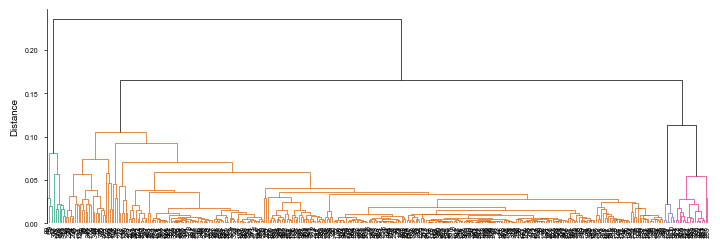

In [12]:
# Define the optimal number of clusters.
k_optimal = 4

# Compute hierarchical linkage.
linked = linkage(nichespace_deepsdm_all, method='average', metric='cosine')

# Generate cluster labels.
cluster_labels = fcluster(linked, t=k_optimal, criterion='maxclust')

# Determine distance threshold.
max_d = linked[-(k_optimal-1), 2]

# Plot the dendrogram.
fig, ax = plt.subplots(figsize=mm2inch(180, 60), constrained_layout = True)
set_link_color_palette(PU.color_list)
d_data = dendrogram(
    linked,
    orientation='top',
    distance_sort='ascending',
    show_leaf_counts=False,
    color_threshold=max_d,
    # labels=[sp.replace('_', ' ') for sp in PU.species_list_predict if sp not in species_list_exclude],
    # labels=[sp.replace('_', ' ') for sp in PU.species_list_predict],     # Use this line if no species_list_exclude
    above_threshold_color = 'black',
    ax = ax
)

# Adjust x-axis tick labels (species names), font size, italic style.
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 5, fontstyle='italic', rotation=90, ha='center', va = 'top')
ax.set_ylabel('Distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Set consistent line width on the dendrogram lines.
for line_collection in ax.collections:
    line_collection.set_linewidth(0.5)

# Adjust tick label spacing.
ax.tick_params(axis='x', which='major', pad=-1)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'nichespace_clustering_dendrogram.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

/home/klok0126/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


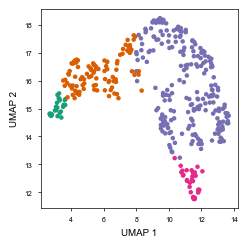

In [13]:
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, OPTICS, SpectralClustering
import matplotlib.pyplot as plt

X = nichespace_deepsdm_all  # 你的資料, e.g. shape (1256, 1505)
k_optimal = 4  # 你想要的群數

# kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
DBSCAN = KMeans(n_clusters=k_optimal, random_state=42)
cluster_labels = DBSCAN.fit_predict(X)
cluster_labels_swapped = cluster_labels.copy()

cluster_labels_swapped[cluster_labels == 0] = 1
cluster_labels_swapped[cluster_labels == 1] = 0
# labels 是與 X 同長度的一維 array，表示每個 species 的 cluster id
# print("cluster counts:", np.bincount(cluster_labels))

# 若你想畫 2D 可視化 (例如先降維再畫)
import umap
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

plt.figure(figsize=mm2inch(60, 60), constrained_layout = True)
plt.scatter(embedding[:,0], embedding[:,1], c=np.array(PU.color_list)[cluster_labels_swapped], s=5)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
# plt.title(f'K-Means clustering (k={k_optimal}) on niche-space')
plt.savefig(os.path.join(PU.plot_path_nichespace_clustering, 'UMAP_cluster.pdf'), transparent = True, dpi = 500)
plt.show()

In [14]:
# from matplotlib import font_manager as fm

# # 設置字體為 Noto Sans CJK
# font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'  # 檢查該路徑是否存在
# font_prop = fm.FontProperties(fname=font_path)

# # Define the optimal number of clusters.
# k_optimal = 3

# # Compute hierarchical linkage.
# linked = linkage(nichespace_deepsdm_all, method='average', metric='cosine')

# # Generate cluster labels.
# cluster_labels = fcluster(linked, t=k_optimal, criterion='maxclust')

# # Determine distance threshold.
# max_d = linked[-(k_optimal-1), 2]

# # Plot the dendrogram.
# fig, ax = plt.subplots(figsize=mm2inch(180, 60), constrained_layout = True)
# set_link_color_palette(PU.color_list)
# d_data = dendrogram(
#     linked,
#     orientation='top',
#     distance_sort='ascending',
#     show_leaf_counts=False,
#     color_threshold=max_d,
#     labels=[get_chinese_sciname(sp) for sp in PU.species_list_predict if sp not in species_list_exclude],
#     above_threshold_color = 'black',
#     ax = ax
# )

# # Adjust x-axis tick labels (species names), font size, italic style.
# ls = [l.get_text() for l in ax.get_xticklabels()]
# vls = ['\n'.join(list(l)) for l in ls]
# ax.set_xticklabels(vls, fontsize = 4, ha='center', va = 'top', fontproperties = font_prop, rotation = 0)
# ax.set_ylabel('Distance')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

# # Set consistent line width on the dendrogram lines.
# for line_collection in ax.collections:
#     line_collection.set_linewidth(0.5)

# # Adjust tick label spacing.
# ax.tick_params(axis='x', which='major', pad=-1)

# plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'nichespace_clustering_dendrogram_chinese.pdf')
# plt.savefig(plot_output, dpi = 500, transparent = True)
# plt.show()

## Generate cluster-level average niches
The following code computes the average niche map for each identified cluster.

In [15]:
all_cluster_avg_niches = PU.get_all_cluster_average_nichespace(cluster_labels_swapped, nichespace_deepsdm_all_nonflatten)
img_sign = np.sign(all_cluster_avg_niches[0][1])

## Write cluster labels and average niche space data
Stores the computed labels and averages to YAML files for subsequent usage.

In [16]:
with open(PU.cluster_labels_path, 'w') as f:
    yaml.dump(cluster_labels_swapped.tolist(), f)
    
all_cluster_avg_niches_converted = {int(i):j.tolist() for i, j in all_cluster_avg_niches}
with open(PU.cluster_avg_nichespace_path, 'w') as f:
    yaml.dump(all_cluster_avg_niches_converted, f)

## Visualization of average niche space per cluster
Here, each cluster's mean niche space is saved as an image.

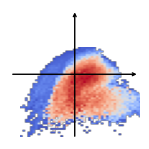

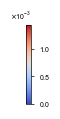

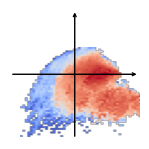

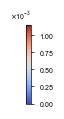

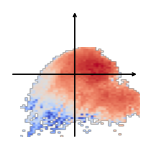

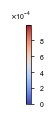

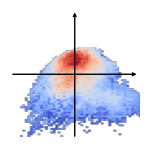

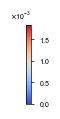

In [17]:
for (i_img, img) in all_cluster_avg_niches:
    fig, ax = plt.subplots(figsize = mm2inch(35, 35), constrained_layout = True)
    img_nan = np.where(img <= 0, np.nan, img)
    ax.imshow(img_nan, vmin = 0, cmap = 'coolwarm', extent = PU.nichespace_extent)
    ax.axis('off')

    # X-axis arrow.
    ax.annotate(
        '',
        xy=(6, 0),
        xytext=(-6, 0),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )

    # Y-axis arrow.
    ax.annotate(
        '',
        xy=(0, 6),
        xytext=(0, -6),
        arrowprops=dict(facecolor='black', arrowstyle='->')
    )
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

    plot_output = os.path.join(PU.plot_path_nichespace_clustering, f'nichespace_avg_cluster{i_img}.pdf')
    plt.savefig(plot_output, transparent = True, dpi = 500)
    plt.show()

    # Plot a separate colorbar for each cluster.
    fig_cb, ax_cb = plt.subplots(figsize = mm2inch(10, 25), gridspec_kw = {'left': 0.38, 'right': 0.5, 'bottom': 0.05, 'top': 0.85})
    norm = plt.Normalize(vmin = 0, vmax = np.nanmax(img_nan))
    cb = fig_cb.colorbar(plt.cm.ScalarMappable(norm = norm, cmap='coolwarm'), cax = ax_cb, orientation = 'vertical')

    formatter = mtick.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax_cb.yaxis.set_major_formatter(formatter)

    cb_output = os.path.join(PU.plot_path_nichespace_clustering, f'nichespace_avg_cluster{i_img}_colorbar.pdf')
    plt.savefig(cb_output, transparent=True, dpi=500)
    plt.show()

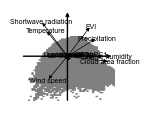

In [18]:
for (i_img, img) in all_cluster_avg_niches:
    if i_img == 0:
        fig, ax = plt.subplots(figsize = mm2inch(35, 35), constrained_layout = True)
        img_nan = np.where(img <= 0, np.nan, img)
        single_cmap = ListedColormap(['grey'])
        single_cmap.set_bad(alpha=0)
        ax.imshow(np.sign(img_nan), vmin = 0, cmap = single_cmap, extent = PU.nichespace_extent)
        ax.axis('off')
    
        # X-axis arrow.
        ax.annotate(
            '',
            xy=(6, 0),
            xytext=(-6, 0),
            arrowprops=dict(facecolor='black', arrowstyle='->')
        )
    
        # Y-axis arrow.
        ax.annotate(
            '',
            xy=(0, 6),
            xytext=(0, -6),
            arrowprops=dict(facecolor='black', arrowstyle='->')
        )
        ax.set_xlim(-6, 6)
        ax.set_ylim(-6, 6)
    
    
        for env, env_name in zip(PU.env_list, PU.env_list_detail):
        
            dx = PU.env_pca_loadings.loc[env][f'PC{PU.x_pca:02d}'] * 6
            dy = PU.env_pca_loadings.loc[env][f'PC{PU.y_pca:02d}'] * 6
        
            ax.annotate(
                '',
                xy=(dx, dy),
                xytext=(0, 0),
                arrowprops=dict(
                    arrowstyle='-|>',
                    lw=0.5,
                    mutation_scale=5,
                    fc='black',
                    shrinkA=0,
                    shrinkB=0
                )
            )
        
            # 文字位置：比箭頭末端再往外一點
            length = np.sqrt(dx**2 + dy**2)
        
            if length == 0:
                label_x, label_y = dx, dy
            else:
                label_x = dx + 0.25 * dx / length
                label_y = dy + 0.25 * dy / length
        
            ax.text(
                label_x,
                label_y,
                env_name,
                fontsize=5,
                ha='center',
                va='center'
            )
    
    
        
        plot_output = os.path.join(PU.plot_path_nichespace_clustering, f'nichespace_env.pdf')
        plt.savefig(plot_output, transparent = True, dpi = 500)
        plt.show()


## Visualization of average niche space per cluster
Here, each cluster's mean niche space is saved as an image.

In [19]:
df_center = PU.calculate_deepsdm_nichespace_center(nichespace_deepsdm_all_nonflatten, cluster_labels_swapped)
# df_center.to_csv(PU.df_nichespace_center_coordinate_path)
df_center

,PC01,PC02,cluster
Abies_kawakamii,0.992847,-1.643414,0
Acacia_confusa,1.090427,-1.289271,2
Acer_albopurpurascens,1.286624,-1.167072,2
Acer_caudatifolium,1.454098,-1.429625,1
Acer_morrisonense,1.594314,-1.485255,1
...,...,...,...
Wendlandia_uvariifolia,1.004357,-0.639463,3
Yushania_niitakayamensis,1.076431,-1.698384,1
Zanthoxylum_nitidum,0.798260,-1.212912,2
Zanthoxylum_scandens,1.128064,-1.349305,2


0
['玉山杜鵑', '銳葉高山櫟', '假繡球', '玉山假沙梨', '水絲梨', '高山白珠樹', '臺灣雲杉', '冬青葉桃仁', '臺灣冷杉', '松田氏莢蒾', '臺灣小檗', '雲南冬青', '臺灣黃杉', '紅毛杜鵑', '高山櫟', '刺葉桂櫻', '刺柏', '阿里山十大功勞', '臺灣鐵杉', '玉山小檗', '臺灣華山松', '樺葉莢蒾', '南湖杜鵑', '苗栗冬青', '香青']
['Rhododendron_pseudochrysanthum', 'Quercus_tatakaensis', 'Viburnum_sympodiale', 'Photinia_niitakayamensis', 'Sycopsis_sinensis', 'Gaultheria_itoana', 'Picea_morrisonicola', 'Prunus_phaeosticta_var._ilicifolia', 'Abies_kawakamii', 'Viburnum_erosum', 'Berberis_kawakamii', 'Ilex_yunnanensis', 'Pseudotsuga_wilsoniana', 'Rhododendron_rubropilosum_var._rubropilosum', 'Quercus_spinosa', 'Prunus_spinulosa', 'Juniperus_formosana_var._formosana', 'Mahonia_oiwakensis', 'Tsuga_chinensis_var._formosana', 'Berberis_morrisonensis', 'Pinus_armandii_var._mastersiana', 'Viburnum_betulifolium', 'Rhododendron_hyperythrum', 'Ilex_bioritsensis', 'Juniperus_squamata']


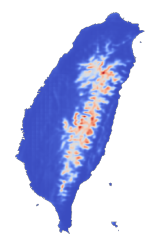

1
['假長葉楠', '深山野牡丹', '臺灣赤楊', '疏果海桐', '無刺伏牛花', '昆欄樹', '小實女貞', '阿里山灰木', '臺灣常春藤', '西施花', '臺灣杜鵑', '臺灣懸鉤子', '臺灣老葉兒樹', '大葉溲疏', '平遮那灰木', '臺灣扁柏', '圓葉冬青', '圓葉鑽地風', '太平山冬青', '珍珠花', '茶葉灰木', '高山莢蒾', '玉山箭竹', '蘭崁馬藍', '尾葉灰木', '玉山糯米樹', '銳葉新木薑子', '深紅茵芋', '大葉石櫟', '月桂葉灰木', '早田氏柃木', '通條樹', '泛能高山茶', '阿里山忍冬', '大枝掛繡球', '臺灣二葉松', '玉山灰木', '臺灣八角金盤', '早田氏冬青', '厚葉柃木', '無脈木犀', '著生珊瑚樹', '凹葉越橘', '南澳杜鵑', '鬼石櫟', '臺灣水青岡', '藤毛木槲', '壺花莢蒾', '銳葉木犀', '粗毛柃木', '枇杷葉灰木', '臺東莢蒾', '狹葉莢蒾', '正藤木槲', '細葉蕗蕨', '紅檜', '阿里山女貞', '石斑木', '太平紅淡比', '桑葉懸鉤子', '秀柱花', '刺果衛矛', '狹葉櫟', '臺灣馬醉木', '臺灣灰木', '守城滿山紅', '東方肉穗野牡丹', '擬日本灰木', '霧社木薑子', '南燭', '臺灣樹參', '臺灣蘋果', '福建賽衛矛', '變葉新木薑子', '臺灣青莢葉', '臺灣紅榨槭', '巒大紫珠', '白花八角', '毛蕊花', '異葉木犀', '紫珠葉泡花', '阿里山千金榆', '毽子櫟', '巒大越橘', '假柃木', '青葉楠', '東瀛珊瑚', '臺灣五葉松', '大葉越橘', '尖葉楓', '玉山木薑子', '薄葉虎皮楠', '小葉莢蒾', '薄葉柃木', '毛柱楊桐', '栓皮櫟', '臺灣鵝掌柴', '高山新木薑子', '赤皮', '雪山冬青', '李氏木薑子']
['Machilus_pseudolongifolia', 'Barthea_barthei', 'Alnus_formosana', 'Pittosporum_illicioides_var._illicioides', 'Damnacanthus_angustifolius', 'Trochodendron_ar

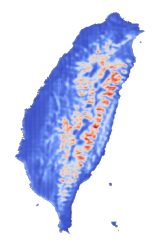

2
['山黃麻', '馬藍', '米碎柃木', '三葉崖爬藤', '鼠刺', '裏白饅頭果', '珊瑚樹', '火燒柯', '山豬肉', '粗糠柴', '屏東木薑子', '拎樹藤', '稜果榕', '長穗馬藍', '筆羅子', '木蠟樹', '五掌楠', '豬腳楠', '藤胡頹子', '銳葉柃木', '軟毛柿', '菱葉衛矛', '山豬肝', '頷垂豆', '石月', '楊桐葉灰木', '薄葉雞屎樹', '臺灣楊桐', '單刺苦櫧', '蓮花池山龍眼', '長葉木薑子', '臺灣石楠', '石苓舅', '臺灣牛彌菜', '白匏子', '油葉石櫟', '黑星紫金牛', '紅皮', '黃藤', '木荷', '酸藤', '豬母乳', '咬人狗', '三腳虌', '九節木', '短角冷水麻', '狹瓣八仙花', '雞屎樹', '雨傘仔', '臺灣肉桂', '樟葉槭', '山紅柿', '玉山紫金牛', '小葉赤楠', '大香葉樹', '臺灣桫欏', '無患子', '錐果櫟', '烏皮茶', '短尾葉石櫟', '茜草樹', '大明橘', '土楠', '金毛杜鵑', '糊樗', '茄冬', '曲莖馬藍', '糙莖菝葜', '野桐', '刺杜密', '杜英', '琉球雞屎樹', '澀葉榕', '硃砂根', '小葉石楠', '短柱山茶', '燈稱花', '墨點櫻桃', '黃杞', '朴樹', '三斗石櫟', '太魯閣櫟', '虎葛', '三葉山香圓', '白雞油', '瓊楠', '樹杞', '牛奶榕', '山櫻花', '大葉木犀', '白肉榕', '森氏紅淡比', '珍珠蓮', '臺灣崖爬藤', '穿鞘花', '鵝掌柴', '長葉苧麻', '山龍眼', '呂宋莢蒾', '臺灣糊樗', '雙面刺', '蟲屎', '藤花椒', '小葉白筆', '海州常山', '大葉楠', '筆筒樹', '菝葜', '亨利氏伊立基藤', '假菝葜', '五節芒', '血桐', '杏葉石櫟', '鬼桫欏', '米飯花', '紅葉樹', '血藤', '光葉柃木', '水金京', '細枝柃木', '密毛小毛蕨', '胡氏肉桂', '桃葉珊瑚', '化香樹', '烏皮九芎', '天仙果', '杜虹花', '毛玉葉金花', '細葉饅頭果', '青楓', '大丁黃', '銳脈木薑子', '後大埔石櫟', '厚皮香',

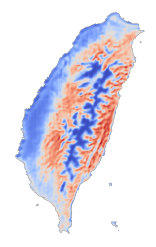

3
['龍眼', '水錦樹', '細刺苦櫧', '臺灣苦櫧', '波葉櫟', '大葉樹蘭', '薄葉玉心花', '烏柑仔', '恆春楨楠', '紅果椌木', '裏白巴豆', '山柚', '捲斗櫟', '白榕', '土密樹', '土樟', '華河瓊楠', '倒卵葉冬青', '細脈赤楠', '七里香', '疏齒紫珠', '印度苦櫧', '毛柿', '南仁五月茶', '烏心石舅', '高士佛赤楠', '恆春厚殼樹', '交力坪鐵色', '臺灣紅豆樹', '柳葉石櫟', '革葉冬青', '紅柴', '星刺栲']
['Dimocarpus_longan', 'Wendlandia_uvariifolia', 'Castanopsis_kusanoi', 'Castanopsis_formosana', 'Quercus_repandifolia', 'Aglaia_elliptifolia', 'Tarenna_gracilipes', 'Severinia_buxifolia', 'Machilus_obovatifolia', 'Dysoxylum_hongkongense', 'Croton_cascarilloides', 'Champereia_manillana', 'Quercus_pachyloma', 'Ficus_benjamina', 'Bridelia_tomentosa', 'Cinnamomum_reticulatum', 'Beilschmiedia_tsangii', 'Ilex_maximowicziana', 'Syzygium_euphlebium', 'Pittosporum_pentandrum', 'Callicarpa_remotiserrulata', 'Castanopsis_indica', 'Diospyros_philippensis', 'Antidesma_hiiranense', 'Magnolia_kachirachirai', 'Syzygium_kusukusense', 'Ehretia_resinosa', 'Drypetes_karapinensis', 'Ormosia_formosana', 'Lithocarpus_dodonaeifolius', 'Ilex_cochinchinensis', 

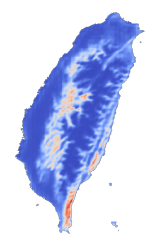

In [20]:
df_change_name = pd.read_csv(os.path.join(PU.plot_path_nichespace_clustering, 'change_name.csv'))
df_center['chinese_name'] = [df_change_name[df_change_name.sciname == sp.replace('_', ' ')].chiname.values[0] for sp in df_center.index.tolist()]
df_center.to_csv(os.path.join(PU.plot_path_nichespace_clustering, 'nichecenter_coordinate_chinese.csv'))

import random
import h5py
for cluster in set(df_center.cluster):
    print(cluster)
    sp_avg_cluster_distribution = np.zeros([PU.height, PU.width])
    sp_list_cluster = df_center[df_center.cluster==cluster].index.tolist()
    sp_list_cluster_random = random.sample(sp_list_cluster, min(500, len(sp_list_cluster)))
    print([df_center[df_center.index==sp].chinese_name.values[0] for sp in sp_list_cluster_random])
    print(sp_list_cluster_random)
    for sp in sp_list_cluster_random:
        sp_avg_distribution = np.zeros([PU.height, PU.width])
        with h5py.File(PU.deepsdm_h5_path.replace('[SPECIES]', sp), 'r') as h5f:
            for key in h5f.keys():
                sp_avg_distribution = sp_avg_distribution + h5f[key][:]
            sp_avg_distribution = sp_avg_distribution/len(h5f.keys())
            
        sp_avg_cluster_distribution = sp_avg_cluster_distribution + sp_avg_distribution
    sp_avg_cluster_distribution = sp_avg_cluster_distribution / len(sp_list_cluster_random)
    fig, ax = plt.subplots(figsize = mm2inch(40, 60), constrained_layout = True)
    ax.imshow(sp_avg_cluster_distribution, cmap = 'coolwarm')
    ax.axis('off')
    fig_path = os.path.join(PU.plot_path_nichespace_clustering, f'biotope_cluster{cluster}.pdf')
    plt.savefig(fig_path)
    plt.savefig(cb_output, transparent=True, dpi=500)
    plt.show()

## Plot the distribution maps of all species (2026/03/30)

In [21]:
with h5py.File('/home/klok0126/DeepSDM_VegTW/predicts/a21e809cf92c477c8e6f67a638adcb03/h5/Abies_kawakamii/Abies_kawakamii.h5', 'r') as h5f:
    print(h5f.keys())

<KeysViewHDF5 ['2003-01-01', '2004-01-01', '2005-01-01', '2006-01-01', '2007-01-01']>


In [20]:
import h5py
from matplotlib import font_manager as fm

font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
font_prop = fm.FontProperties(fname=font_path)
biotope_per_species_pdf_path = os.path.join(PU.plot_path_nichespace_clustering, 'biotope_per_species_pdf')
create_folder(biotope_per_species_pdf_path)

In [ ]:
species_list_plot = list(set(PU.species_list_predict) & set(species_list_filter))

In [ ]:
change_name_path = os.path.join(PU.plot_path_nichespace_clustering, 'change_name.csv')
change_name = pd.read_csv(change_name_path, index_col=None)

In [30]:
for sp in species_list_plot:
    sp_chinese = change_name[change_name.sciname == sp.replace('_', ' ')]['chiname'].values[0]
    sp_distribution = np.zeros([PU.height, PU.width])
    with h5py.File(PU.deepsdm_h5_path.replace('[SPECIES]', sp), 'r') as h5f:
        i_year = 0
        for key in h5f.keys():
            sp_distribution = sp_distribution + h5f[key][:].copy()
            i_year += 1
    sp_distribution = sp_distribution / i_year
    
    fig, ax = plt.subplots(figsize = mm2inch(40, 60), constrained_layout = True)
    im = ax.imshow(sp_distribution, cmap = 'coolwarm')
    ax.set_title(f'{sp_chinese}\n{sp.replace('_', ' ')}', fontproperties = font_prop, size = 5)
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, fraction=0.05, location = 'bottom', shrink = 0.7)
    fig_path = os.path.join(biotope_per_species_pdf_path, f'biotope_{sp_chinese}_{sp}.pdf')
    plt.savefig(fig_path, transparent=True, dpi=500)
    plt.close()

In [27]:
biotope_per_species_png_path = os.path.join(PU.plot_path_nichespace_clustering, 'biotope_per_species_png')
create_folder(biotope_per_species_png_path)

for sp in species_list_plot:
    sp_chinese = change_name[change_name.sciname == sp.replace('_', ' ')]['chiname'].values[0]
    sp_distribution = np.zeros([PU.height, PU.width])
    with h5py.File(PU.deepsdm_h5_path.replace('[SPECIES]', sp), 'r') as h5f:
        i_year = 0
        for key in h5f.keys():
            sp_distribution = sp_distribution + h5f[key][:].copy()
            i_year += 1
    sp_distribution = sp_distribution / i_year
    
    fig, ax = plt.subplots(figsize = mm2inch(40, 60), constrained_layout = True)
    im = ax.imshow(sp_distribution, cmap = 'coolwarm')
    ax.set_title(f'{sp_chinese}\n{sp.replace('_', ' ')}', fontproperties = font_prop, size = 5)
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, fraction=0.05, location = 'bottom', shrink = 0.7)
    fig_path = os.path.join(biotope_per_species_png_path, f'biotope_{sp_chinese}_{sp}.png')
    plt.savefig(fig_path, transparent=True, dpi=500)
    plt.close()

## Compute LDA of clustered niche centers

In [22]:
df_lda_result, df_ldaonPC, lda_explained_ratio, k_fold_validation = PU.calculate_nichecenter_cluster_lda()
df_lda_result

Stratified 5-fold CV accuracy: 0.905 (± 0.024)


,variable,importance_pc,loading_PC1,loading_PC2,proj_on_LD1,proj_on_LD2
0,rsds,4.130083e-01,-0.537032,0.717218,0.889689,-0.227504
1,tas,2.370518e-01,-0.437249,0.526244,0.674412,-0.140046
2,clt,1.504697e-01,0.861204,-0.112536,-0.528344,-0.447600
3,hurs,7.951662e-02,0.750239,-0.001479,-0.376667,-0.465529
4,EVI,6.086009e-02,0.472394,0.612831,0.294236,-0.773686
5,sfcWind,3.586716e-02,-0.402104,-0.487190,-0.220624,0.631587
6,landcover_PC01,1.160077e-02,0.334892,0.032108,-0.139765,-0.233460
7,pr,1.157573e-02,0.591127,0.366383,0.021448,-0.654581
8,landcover_PC02,3.353358e-05,0.030225,0.011736,-0.004962,-0.027990
9,landcover_PC04,1.603913e-05,0.016121,0.012985,0.003177,-0.020195


In [23]:
df_ldaonPC.LD1.PC02 / df_ldaonPC.LD1.PC01

-1.730409419501861

## Overlap visualization of average clusters in niche space
Combines the top 50% density areas of each cluster's average niche, plus PCA loadings vectors.

In [24]:
unique_labels, label_to_color = PU.align_label_to_color(k_optimal, cluster_labels_swapped)

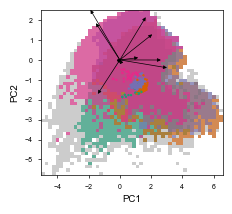

In [25]:
fig, ax = plt.subplots(figsize=mm2inch(55, 50), 
                       gridspec_kw = {'left': 0.15, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Display the background mask (significant region) in grey with transparency
ax.imshow(np.where(img_sign == 1, img_sign, np.nan),
          alpha=0.4,
          extent=PU.nichespace_extent,
          cmap=ListedColormap('grey'))
ax.set_aspect('auto')

# Overlay each cluster’s average niche region
for i_cluster, lbl in enumerate(unique_labels):
    # Get average niche map for the current cluster
    cluster_i_avg_niche = np.where(all_cluster_avg_niches[i_cluster][1] > 0,
                                   all_cluster_avg_niches[i_cluster][1],
                                   np.nan)
    # Define the threshold (50th percentile of non-NaN values)
    cluster_i_threshold = np.nanpercentile(cluster_i_avg_niche, 50)
    
    # Create a single-color colormap for this cluster
    single_cmap = ListedColormap([label_to_color[int(lbl)]]).copy()
    single_cmap.set_bad(alpha=0)
    
    # Display the thresholded cluster region
    ax.imshow(np.where(cluster_i_avg_niche >= cluster_i_threshold, 1, np.nan),
              extent=PU.nichespace_extent,
              cmap=single_cmap,
              alpha=0.6)
    ax.set_aspect('auto')

# Draw environmental variable vectors from the origin
for env in PU.env_list:
    dx = PU.env_pca_loadings.loc[env][f'PC{PU.x_pca:02d}'] * 3.5
    dy = PU.env_pca_loadings.loc[env][f'PC{PU.y_pca:02d}'] * 3.5
    ax.annotate(
        '',                              # No text, just an arrow
        xy=(dx, dy),                     # Arrow tip (end)
        xytext=(0, 0),                   # Arrow base (start)
        arrowprops=dict(
            arrowstyle='-|>',            # Arrowhead style
            lw=0.5,                      # Line width
            mutation_scale=5,            # Scale factor for arrowhead size (pt)
            fc='black',                  # Fill color (black)
            shrinkA=0,
            shrinkB=0
        )
    )

# Axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Scatter plot of species niche centroids, colored by cluster label
point_colors = [label_to_color[int(lbl)] for lbl in cluster_labels_swapped]
ax.scatter(x=df_center['PC01'],
           y=df_center['PC02'],
           c=point_colors,
           s=0.5)

# Save figure as a transparent high-resolution PDF
plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'cluster_mean_env.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)

# Display the final figure
plt.show()

## Plot species niche centroids and the largest variance direction
Scatter plot of species-level PC1 vs PC2 plus a dashed line representing direction of maximum variance.

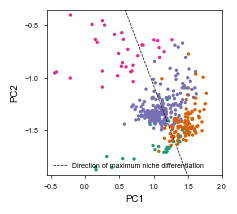

In [26]:
fig, ax = plt.subplots(figsize=mm2inch(55, 50), 
                       gridspec_kw = {'left': 0.18, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Scatter plot of species niche centroids in environmental PCA space
ax.scatter(x=df_center['PC01'],
           y=df_center['PC02'],
           c=point_colors,
           s=2)

# Calculate the centroid of all points (used to center the line of maximum variation)
center_x = df_center["PC01"].mean()
center_y = df_center["PC02"].mean()

# Compute and plot the line representing the direction of maximum variation among species niche centroids
# Equation: y = slope * (x - center_x) + center_y
x_vals_shifted = np.linspace(df_center["PC01"].min(), df_center["PC01"].max()+0.1, 100)
y_vals_shifted = df_ldaonPC.LD1.PC02 / df_ldaonPC.LD1.PC01 * (x_vals_shifted - center_x) + center_y

ax.plot(x_vals_shifted, y_vals_shifted,
        color="black",
        linestyle="--",
        linewidth=0.5,
        label="Direction of maximum niche differentiation")

# Add legend
ax.legend(loc='lower left', frameon=False)

# Axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Define tick positions for both axes
ax.set_xticks([-0.5, 0, 0.5, 1, 1.5, 2])
ax.set_yticks([-2, -1.5, -1.0, -0.5])

# Set y-axis range slightly beyond data limits for better spacing
ax.set_ylim([df_center["PC02"].min() - 0.05,
             df_center["PC02"].max() + 0.05])

# Save figure as a transparent high-resolution PDF
plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'niche_center_LDAaxis1.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)

# Display plot
plt.show()


## Plot importance of environmental factors of LDA
Displays the importance of each environmental factor to LDA result.

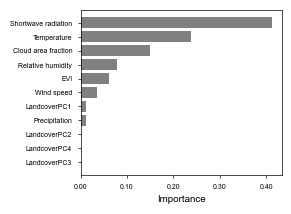

In [27]:
fig, ax = plt.subplots(figsize=mm2inch(70, 50), 
                       gridspec_kw = {'left': 0.26, 'right': 0.99, 'bottom': 0.15, 'top': 0.99})

# Get y-axis labels (according to the mapping in env_list_change dictionary)
y_labels = convert_to_env_list_detail(df_lda_result.variable)

# Plot each bar
for i, (env, value) in enumerate(zip(df_lda_result.variable,
                                     df_lda_result.importance_pc)):
    ax.barh(y_labels[i], value, color="grey")

# Set x-axis label
ax.set_xlabel("Importance")

# Set custom x-axis ticks
ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# Invert y-axis to show the most correlated variable at the top
ax.invert_yaxis()

# Remove background grid lines
ax.grid(False)

plot_output = os.path.join(PU.plot_path_nichespace_clustering, 'lda_importance.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)
plt.show()

## Environmental medians violin plots of species among three clusters

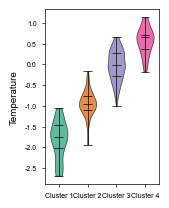

Overall Kruskal–Wallis (4 clusters): H=263.779, p=6.84e-57
Pairwise results (species-level medians):
  Cluster 0 vs Cluster 1: H=50.311, p=1.31e-12
  Cluster 0 vs Cluster 2: H=67.137, p=2.53e-16
  Cluster 0 vs Cluster 3: H=41.952, p=9.36e-11
  Cluster 1 vs Cluster 2: H=184.724, p=4.51e-42
  Cluster 1 vs Cluster 3: H=73.978, p=7.9e-18
  Cluster 2 vs Cluster 3: H=51.100, p=8.78e-13
[Saved] Updated results for 'tas' to: plots/a21e809cf92c477c8e6f67a638adcb03/FigSuppl/cluster_env_values_stats.json


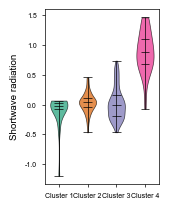

Overall Kruskal–Wallis (4 clusters): H=83.794, p=4.71e-18
Pairwise results (species-level medians):
  Cluster 0 vs Cluster 1: H=6.648, p=0.00992
  Cluster 0 vs Cluster 2: H=0.558, p=0.455
  Cluster 0 vs Cluster 3: H=38.369, p=5.85e-10
  Cluster 1 vs Cluster 2: H=3.221, p=0.0727
  Cluster 1 vs Cluster 3: H=66.452, p=3.59e-16
  Cluster 2 vs Cluster 3: H=74.228, p=6.96e-18
[Saved] Updated results for 'rsds' to: plots/a21e809cf92c477c8e6f67a638adcb03/FigSuppl/cluster_env_values_stats.json


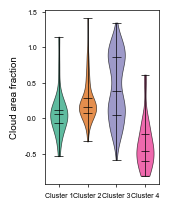

Overall Kruskal–Wallis (4 clusters): H=86.448, p=1.27e-18
Pairwise results (species-level medians):
  Cluster 0 vs Cluster 1: H=11.610, p=0.000656
  Cluster 0 vs Cluster 2: H=13.787, p=0.000205
  Cluster 0 vs Cluster 3: H=23.161, p=1.49e-06
  Cluster 1 vs Cluster 2: H=11.613, p=0.000655
  Cluster 1 vs Cluster 3: H=55.726, p=8.33e-14
  Cluster 2 vs Cluster 3: H=63.569, p=1.55e-15
[Saved] Updated results for 'clt' to: plots/a21e809cf92c477c8e6f67a638adcb03/FigSuppl/cluster_env_values_stats.json


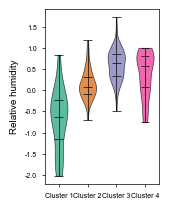

Overall Kruskal–Wallis (4 clusters): H=127.751, p=1.65e-27
Pairwise results (species-level medians):
  Cluster 0 vs Cluster 1: H=34.236, p=4.88e-09
  Cluster 0 vs Cluster 2: H=54.665, p=1.43e-13
  Cluster 0 vs Cluster 3: H=24.385, p=7.89e-07
  Cluster 1 vs Cluster 2: H=88.327, p=5.55e-21
  Cluster 1 vs Cluster 3: H=7.878, p=0.005
  Cluster 2 vs Cluster 3: H=4.126, p=0.0422
[Saved] Updated results for 'hurs' to: plots/a21e809cf92c477c8e6f67a638adcb03/FigSuppl/cluster_env_values_stats.json


In [10]:
# for env in PU.env_list:
for env in ['tas', 'rsds', 'clt', 'hurs']:
    PU.species_occ_env_violinplot(env, species_list_exclude)